In [49]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mahyeks/pothrgbd-rgb-and-depth-images-of-potholes")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Admin\.cache\kagglehub\datasets\mahyeks\pothrgbd-rgb-and-depth-images-of-potholes\versions\1


In [50]:
def find_pothole_root(base):
    for root, dirs, files in os.walk(base):
        if "PUBLIC POTHOLE DATASET" in dirs:
            return os.path.join(root, "PUBLIC POTHOLE DATASET")
    return None

path = find_pothole_root(path)
print("POTHOLE_ROOT:", path)

POTHOLE_ROOT: C:\Users\Admin\.cache\kagglehub\datasets\mahyeks\pothrgbd-rgb-and-depth-images-of-potholes\versions\1\PUBLIC POTHOLE DATASET


In [51]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# base_path = Path('/kaggle/input/pothrgbd-rgb-and-depth-images-of-potholes/PUBLIC POTHOLE DATASET')
base_path = Path(r'C:\Users\Admin\.cache\kagglehub\datasets\mahyeks\pothrgbd-rgb-and-depth-images-of-potholes\versions\1\PUBLIC POTHOLE DATASET')
# images_dir = base_path / 'images'
# depths_dir = base_path / 'depths'
# labels_dir = base_path / 'labels'

images_dir = os.path.join(base_path,'images')
depths_dir = os.path.join(base_path,'depths')
labels_dir = os.path.join(base_path,'labels')

In [52]:
print(type(images_dir))
print(images_dir)

<class 'str'>
C:\Users\Admin\.cache\kagglehub\datasets\mahyeks\pothrgbd-rgb-and-depth-images-of-potholes\versions\1\PUBLIC POTHOLE DATASET\images


In [53]:
import glob
# image_files = sorted(list(images_dir.glob('*.jpg')))
# depth_files = sorted(list(depths_dir.glob('*.npy')))
# label_files = sorted(list(labels_dir.glob('*.txt')))
image_files = sorted(glob.glob(images_dir + "/*.jpg"))
depth_files = sorted(glob.glob(depths_dir + "/*.npy"))
label_files = sorted(glob.glob(labels_dir + "/*.txt"))

idx = np.random.randint(0, len(image_files))

img = cv2.cvtColor(cv2.imread(str(image_files[idx])), cv2.COLOR_BGR2RGB)
depth = np.load(depth_files[idx])  # Depth maps are stored as .npy files

/kaggle/input/pothrgbd-rgb-and-depth-images-of-potholes/PUBLIC POTHOLE DATASET

In [54]:
print("Images:", len(image_files))
print("Depth files:", len(depth_files))
print("Labels:", len(label_files))

Images: 1000
Depth files: 1000
Labels: 1000


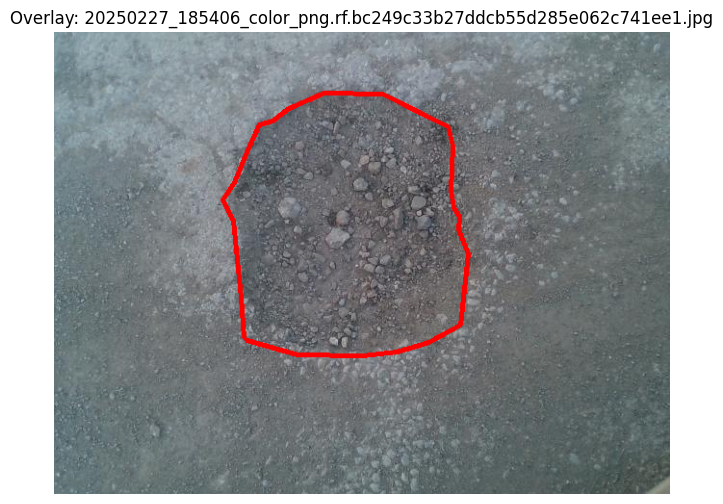

In [55]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def plot_with_labels(image_path, label_path):
    # Load the RGB image
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    with open(label_path, 'r') as f:
        for line in f:
            coords = line.split()[1:]
            points = np.array([float(x) for x in coords]).reshape(-1, 2)
            points[:, 0] *= w
            points[:, 1] *= h
            points = points.astype(np.int32)

            cv2.polylines(img, [points], isClosed=True, color=(255, 0, 0), thickness=3)

    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.title(f"Overlay: {os.path.basename(image_path)}")
    plt.axis('off')
    plt.show()

plot_with_labels(image_files[200], label_files[200])

✓ Found 1000 RGB images
✓ Found 1000 depth maps
✓ Found 1000 label files

PART 1: DEPTH DATA ANALYSIS

Analyzing first 20 depth maps...

 Depth Map Statistics:
  Shape (all should match): {(480, 640)}
  Min depth value: 0.00
  Max depth value: 16515.00
  Average mean depth: 969.03
  Average median depth: 1009.20
  Zeros per image (avg): 19045 pixels
  Non-zero per image (avg): 288155 pixels

PART 2: RGB-DEPTH ALIGNMENT CHECK

Sample #200:
  RGB shape: (480, 640, 3)
  Depth shape: (480, 640)
  Aligned: ✓ YES

PART 3: DETAILED SAMPLE ANALYSIS

Depth Map #200 Details:
  Data type: uint16
  Min value: 0.00
  Max value: 1360.00
  Mean: 1159.70
  Median: 1225.00
  Std dev: 289.37
  Zeros: 16994 pixels (5.5%)

Depth value distribution:
  10th percentile: 1130.00
  25th percentile: 1164.00
  50th percentile: 1232.00
  75th percentile: 1292.00
  90th percentile: 1320.00
  95th percentile: 1326.00
  99th percentile: 1336.00

PART 4: SEGMENTATION MASK ANALYSIS

Mask for sample #200:
  Mask shape:

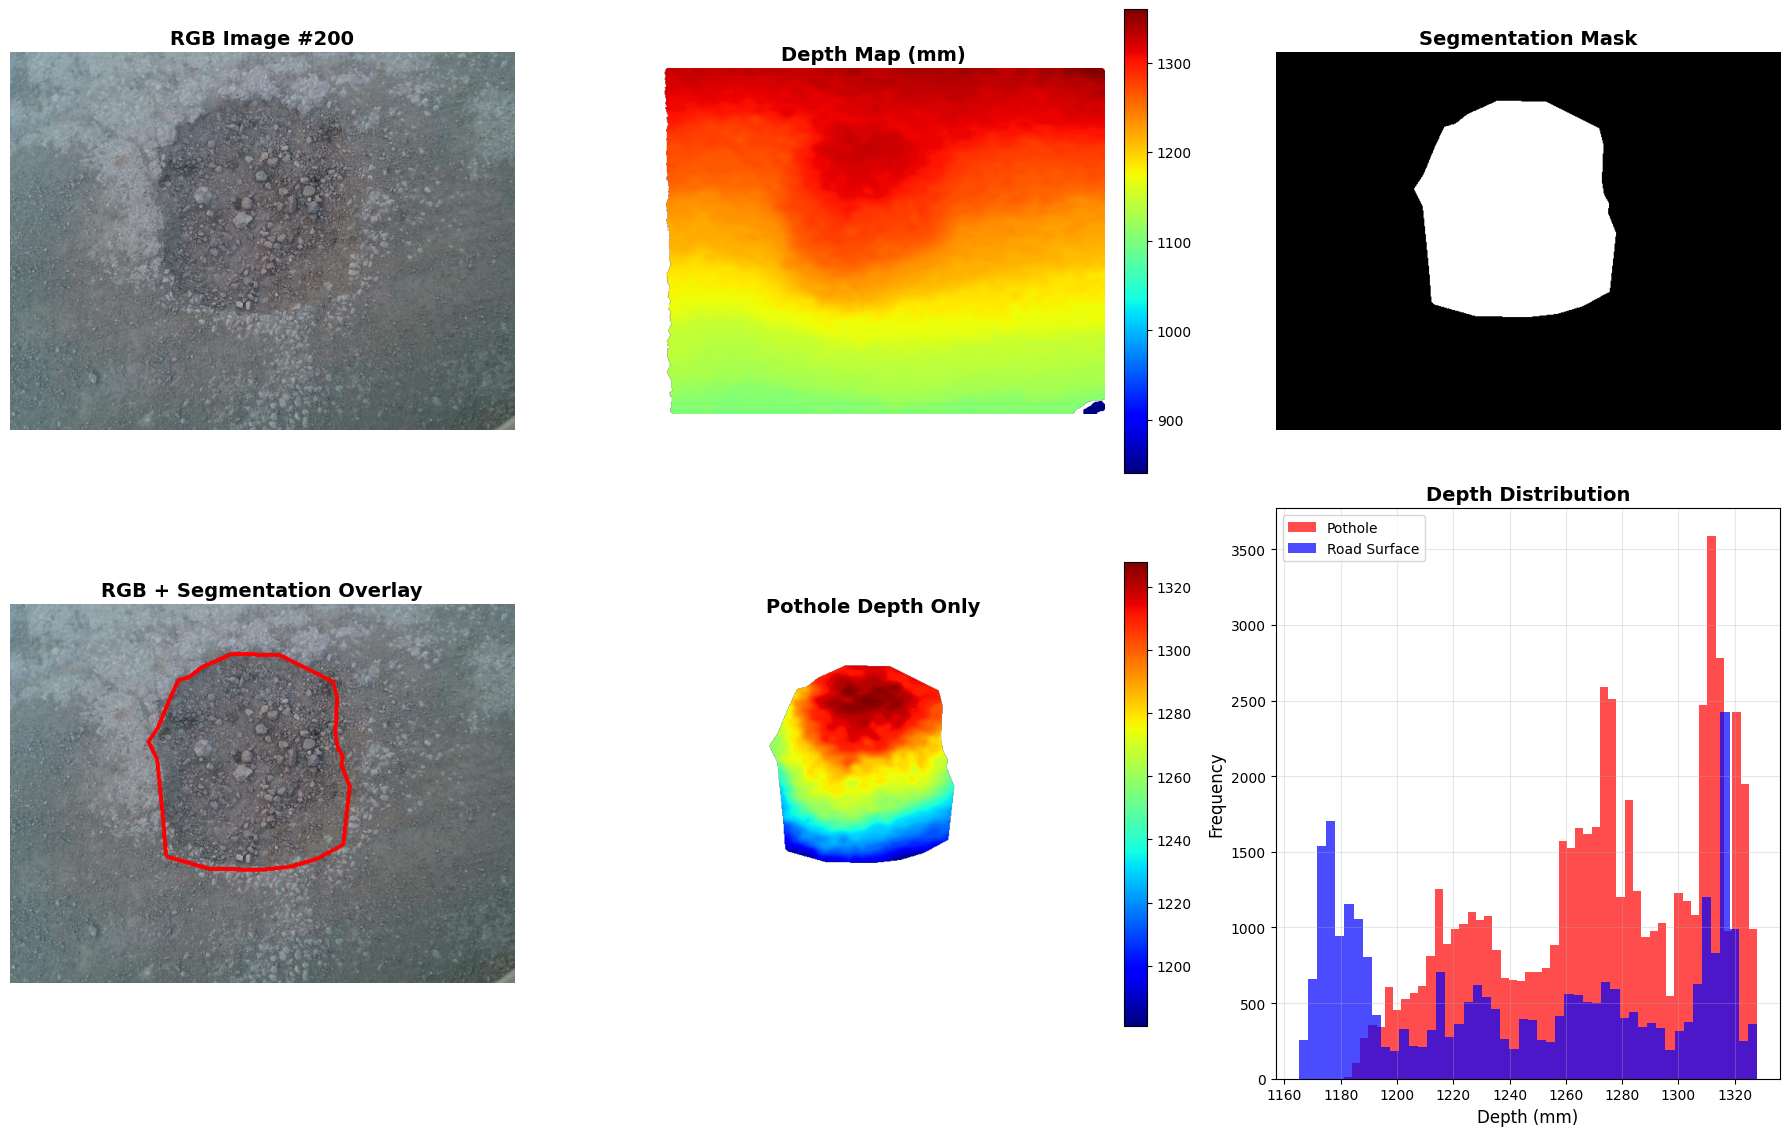


PART 7: MULTI-SAMPLE CONSISTENCY CHECK

Checking 10 random samples for depth difference consistency...
  Sample 275: Road=1035.0mm, Pothole=1054.0mm, Diff=19.0mm
  Sample 972: Road=717.0mm, Pothole=768.0mm, Diff=51.0mm
  Sample 495: Road=1100.0mm, Pothole=1110.0mm, Diff=10.0mm
  Sample 518: Road=471.0mm, Pothole=473.0mm, Diff=2.0mm
  Sample 512: Road=752.0mm, Pothole=700.0mm, Diff=52.0mm
  Sample 815: Road=290.0mm, Pothole=286.0mm, Diff=4.0mm
  Sample 328: Road=682.0mm, Pothole=700.0mm, Diff=18.0mm
  Sample 788: Road=1081.0mm, Pothole=1135.0mm, Diff=54.0mm
  Sample 835: Road=679.0mm, Pothole=696.0mm, Diff=17.0mm
  Sample 780: Road=519.0mm, Pothole=522.0mm, Diff=3.0mm

 Summary of depth differences:
  Mean: 23.0 mm
  Median: 17.5 mm
  Min: 2.0 mm
  Max: 54.0 mm
  Std Dev: 20.1 mm


In [56]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# base_path = Path('/kaggle/input/pothrgbd-rgb-and-depth-images-of-potholes/PUBLIC POTHOLE DATASET')
# images_dir = base_path / 'images'
# depths_dir = base_path / 'depths'
# labels_dir = base_path / 'labels'


# image_files = sorted(list(images_dir.glob('*.jpg')))
# depth_files = sorted(list(depths_dir.glob('*.npy')))
# label_files = sorted(list(labels_dir.glob('*.txt')))

print(f"✓ Found {len(image_files)} RGB images")
print(f"✓ Found {len(depth_files)} depth maps")
print(f"✓ Found {len(label_files)} label files")
print()


print("PART 1: DEPTH DATA ANALYSIS")


depth_stats = {
    'shapes': [],
    'mins': [],
    'maxs': [],
    'means': [],
    'medians': [],
    'zeros_count': [],
    'non_zeros_count': []
}

print("\nAnalyzing first 20 depth maps...")
for i in range(min(20, len(depth_files))):
    depth = np.load(depth_files[i])
    depth_stats['shapes'].append(depth.shape)
    depth_stats['mins'].append(depth.min())
    depth_stats['maxs'].append(depth.max())
    depth_stats['means'].append(depth.mean())
    depth_stats['medians'].append(np.median(depth))
    depth_stats['zeros_count'].append(np.sum(depth == 0))
    depth_stats['non_zeros_count'].append(np.sum(depth > 0))

print("\n Depth Map Statistics:")
print(f"  Shape (all should match): {set(depth_stats['shapes'])}")
print(f"  Min depth value: {min(depth_stats['mins']):.2f}")
print(f"  Max depth value: {max(depth_stats['maxs']):.2f}")
print(f"  Average mean depth: {np.mean(depth_stats['means']):.2f}")
print(f"  Average median depth: {np.mean(depth_stats['medians']):.2f}")
print(f"  Zeros per image (avg): {np.mean(depth_stats['zeros_count']):.0f} pixels")
print(f"  Non-zero per image (avg): {np.mean(depth_stats['non_zeros_count']):.0f} pixels")
print()


print("PART 2: RGB-DEPTH ALIGNMENT CHECK")

idx = 200  # Same index as your example
img = cv2.imread(str(image_files[idx]))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
depth = np.load(depth_files[idx])

print(f"\nSample #{idx}:")
print(f"  RGB shape: {img.shape}")
print(f"  Depth shape: {depth.shape}")
print(f"  Aligned: {'✓ YES' if img.shape[:2] == depth.shape else '✗ NO'}")
print()

print("PART 3: DETAILED SAMPLE ANALYSIS")

print(f"\nDepth Map #{idx} Details:")
print(f"  Data type: {depth.dtype}")
print(f"  Min value: {depth.min():.2f}")
print(f"  Max value: {depth.max():.2f}")
print(f"  Mean: {depth.mean():.2f}")
print(f"  Median: {np.median(depth):.2f}")
print(f"  Std dev: {depth.std():.2f}")
print(f"  Zeros: {np.sum(depth == 0)} pixels ({100*np.sum(depth == 0)/depth.size:.1f}%)")
print()

# Check depth distribution
print("Depth value distribution:")
percentiles = [10, 25, 50, 75, 90, 95, 99]
for p in percentiles:
    val = np.percentile(depth[depth > 0], p) if np.any(depth > 0) else 0
    print(f"  {p}th percentile: {val:.2f}")
print()


print("PART 4: SEGMENTATION MASK ANALYSIS")


def load_yolo_mask(label_path, img_shape):
    """Convert YOLO segmentation to binary mask"""
    h, w = img_shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)
    
    with open(label_path, 'r') as f:
        for line in f:
            coords = line.split()[1:]
            points = np.array([float(x) for x in coords]).reshape(-1, 2)
            points[:, 0] *= w
            points[:, 1] *= h
            points = points.astype(np.int32)
            cv2.fillPoly(mask, [points], 255)
    
    return mask

mask = load_yolo_mask(label_files[idx], img.shape)
print(f"\nMask for sample #{idx}:")
print(f"  Mask shape: {mask.shape}")
print(f"  Pothole pixels: {np.sum(mask > 0)} ({100*np.sum(mask > 0)/mask.size:.2f}%)")
print(f"  Background pixels: {np.sum(mask == 0)} ({100*np.sum(mask == 0)/mask.size:.2f}%)")
print()

masked_depth = depth.copy()
masked_depth[mask == 0] = 0

pothole_depth_values = depth[mask > 0]
background_depth_values = depth[mask == 0]

print("Depth values inside pothole mask:")
if len(pothole_depth_values) > 0:
    print(f"  Count: {len(pothole_depth_values)}")
    print(f"  Min: {pothole_depth_values.min():.2f}")
    print(f"  Max: {pothole_depth_values.max():.2f}")
    print(f"  Mean: {pothole_depth_values.mean():.2f}")
    print(f"  Median: {np.median(pothole_depth_values):.2f}")
else:
    print("  No valid depth values in pothole region!")
print()

print("Depth values outside pothole (road surface):")
if len(background_depth_values[background_depth_values > 0]) > 0:
    valid_bg = background_depth_values[background_depth_values > 0]
    print(f"  Count: {len(valid_bg)}")
    print(f"  Min: {valid_bg.min():.2f}")
    print(f"  Max: {valid_bg.max():.2f}")
    print(f"  Mean: {valid_bg.mean():.2f}")
    print(f"  Median: {np.median(valid_bg):.2f}")
print()

print("PART 5: DEPTH DIFFERENCE ANALYSIS")

kernel = np.ones((50, 50), np.uint8)
dilated_mask = cv2.dilate(mask, kernel, iterations=1)
road_surface_mask = (dilated_mask > 0) & (mask == 0)

road_surface_depths = depth[road_surface_mask & (depth > 0)]

if len(road_surface_depths) > 0 and len(pothole_depth_values) > 0:
    road_surface_depth = np.median(road_surface_depths)
    pothole_median_depth = np.median(pothole_depth_values)
    
    print(f"\n Critical Measurements:")
    print(f"  Road surface depth (median): {road_surface_depth:.2f}")
    print(f"  Pothole depth (median): {pothole_median_depth:.2f}")
    print(f"  Depth difference: {abs(road_surface_depth - pothole_median_depth):.2f}")
    print()
    
    if pothole_median_depth > road_surface_depth:
        print("    Pothole appears FARTHER than road surface (expected for Intel RealSense)")
        print("     Depth increases with distance from camera")
    else:
        print("    Unexpected: Pothole appears CLOSER than road surface")
        print("     This might indicate measurement issues")
else:
    print("    Cannot compute depth difference - insufficient valid data")
print()

print("PART 6: CREATING VISUALIZATIONS")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

axes[0, 0].imshow(img)
axes[0, 0].set_title(f'RGB Image #{idx}', fontsize=14, fontweight='bold')
axes[0, 0].axis('off')

depth_display = depth.astype(float)  
depth_display[depth_display == 0] = np.nan  
im1 = axes[0, 1].imshow(depth_display, cmap='jet')
axes[0, 1].set_title('Depth Map (mm)', fontsize=14, fontweight='bold')
axes[0, 1].axis('off')
plt.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)

axes[0, 2].imshow(mask, cmap='gray')
axes[0, 2].set_title('Segmentation Mask', fontsize=14, fontweight='bold')
axes[0, 2].axis('off')

img_overlay = img.copy()
h, w = img.shape[:2]
with open(label_files[idx], 'r') as f:
    for line in f:
        coords = line.split()[1:]
        points = np.array([float(x) for x in coords]).reshape(-1, 2)
        points[:, 0] *= w
        points[:, 1] *= h
        points = points.astype(np.int32)
        cv2.polylines(img_overlay, [points], isClosed=True, color=(255, 0, 0), thickness=3)

axes[1, 0].imshow(img_overlay)
axes[1, 0].set_title('RGB + Segmentation Overlay', fontsize=14, fontweight='bold')
axes[1, 0].axis('off')

masked_depth_display = masked_depth.astype(float) 
masked_depth_display[masked_depth_display == 0] = np.nan
im2 = axes[1, 1].imshow(masked_depth_display, cmap='jet')
axes[1, 1].set_title('Pothole Depth Only', fontsize=14, fontweight='bold')
axes[1, 1].axis('off')
plt.colorbar(im2, ax=axes[1, 1], fraction=0.046, pad=0.04)

axes[1, 2].hist(pothole_depth_values[pothole_depth_values > 0], bins=50, alpha=0.7, color='red', label='Pothole')
if len(road_surface_depths) > 0:
    axes[1, 2].hist(road_surface_depths, bins=50, alpha=0.7, color='blue', label='Road Surface')
axes[1, 2].set_xlabel('Depth (mm)', fontsize=12)
axes[1, 2].set_ylabel('Frequency', fontsize=12)
axes[1, 2].set_title('Depth Distribution', fontsize=14, fontweight='bold')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('depth_exploration_visualization.png', dpi=150, bbox_inches='tight')
print("✓ Saved: depth_exploration_visualization.png")
plt.show()

print("\n" + "="*70)
print("PART 7: MULTI-SAMPLE CONSISTENCY CHECK")


print("\nChecking 10 random samples for depth difference consistency...")
random_indices = np.random.choice(len(image_files), min(10, len(image_files)), replace=False)

depth_differences = []
for i, idx in enumerate(random_indices):
    depth = np.load(depth_files[idx])
    mask = load_yolo_mask(label_files[idx], depth.shape + (3,))
    
    kernel = np.ones((50, 50), np.uint8)
    dilated_mask = cv2.dilate(mask, kernel, iterations=1)
    road_surface_mask = (dilated_mask > 0) & (mask == 0)
    
    pothole_depths = depth[mask > 0]
    road_depths = depth[road_surface_mask & (depth > 0)]
    
    if len(pothole_depths) > 0 and len(road_depths) > 0:
        road_depth = np.median(road_depths)
        pothole_depth = np.median(pothole_depths)
        diff = abs(road_depth - pothole_depth)
        depth_differences.append(diff)
        print(f"  Sample {idx}: Road={road_depth:.1f}mm, Pothole={pothole_depth:.1f}mm, Diff={diff:.1f}mm")

if len(depth_differences) > 0:
    print(f"\n Summary of depth differences:")
    print(f"  Mean: {np.mean(depth_differences):.1f} mm")
    print(f"  Median: {np.median(depth_differences):.1f} mm")
    print(f"  Min: {np.min(depth_differences):.1f} mm")
    print(f"  Max: {np.max(depth_differences):.1f} mm")
    print(f"  Std Dev: {np.std(depth_differences):.1f} mm")

POTHOLE VOLUME ESTIMATION

Processing sample #200...

----------------------------------------------------------------------
Method 1: Simple (constant pixel area)
----------------------------------------------------------------------
Volume: 10828.89 cm³ (10.8289 L)
Max depth: 82.0 mm
Surface area: 3265.05 cm²

----------------------------------------------------------------------
Method 2: Variable pixel area (RECOMMENDED)
----------------------------------------------------------------------
Volume: 11350.60 cm³ (11.3506 L)
Max depth: 82.0 mm
Surface area: 3265.05 cm²

----------------------------------------------------------------------
Method 3: Interpolated surface
----------------------------------------------------------------------
Volume: 6707.92 cm³ (6.7079 L)
Max depth: 82.0 mm
Surface area: 3265.05 cm²

Creating visualization...
✓ Saved visualization: pothole_volume_analysis.png

BATCH PROCESSING - 10 Random Samples
Sample 348: Vol=35059.1cm³, MaxDepth=202.0mm, Area=5384.

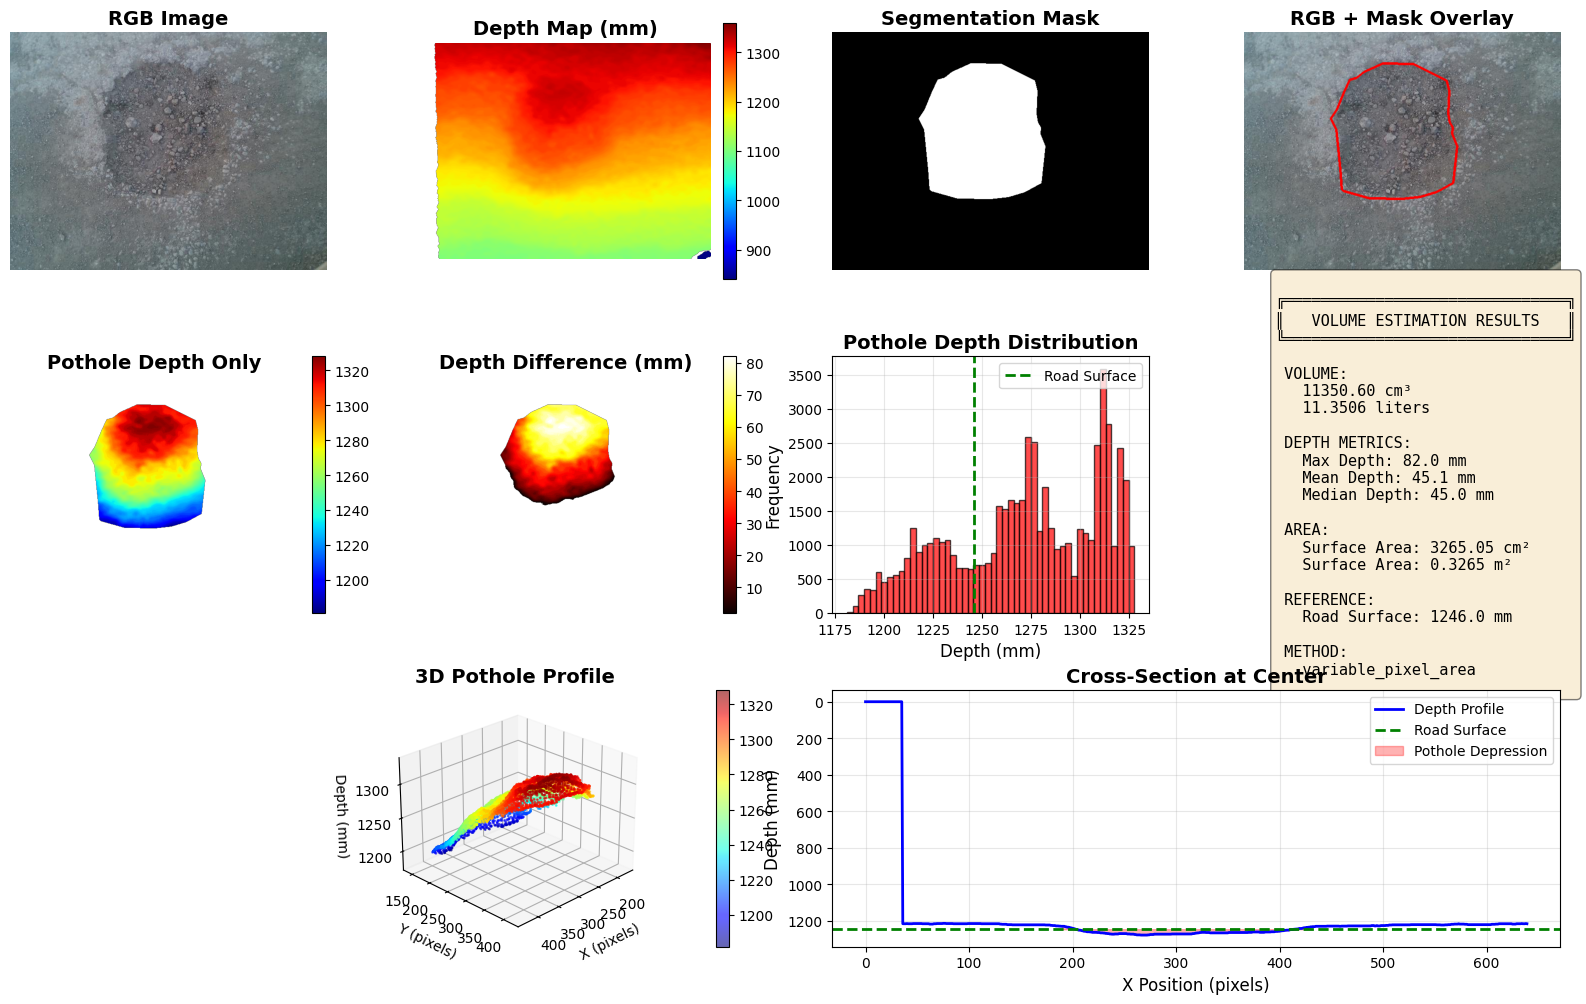

In [58]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from mpl_toolkits.mplot3d import Axes3D
from scipy import ndimage


def load_yolo_mask(label_path, img_shape):
    """Convert YOLO segmentation to binary mask"""
    h, w = img_shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)
    
    if not os.path.exists(label_path):
        return mask
    
    with open(label_path, 'r') as f:
        for line in f:
            coords = line.split()[1:]
            if len(coords) < 6:  
                continue
            points = np.array([float(x) for x in coords]).reshape(-1, 2)
            points[:, 0] *= w
            points[:, 1] *= h
            points = points.astype(np.int32)
            cv2.fillPoly(mask, [points], 255)
    
    return mask


def get_pixel_area_mm2(depth_mm, camera_fov_h=69.4, camera_fov_v=42.5, img_width=640, img_height=480):

    fov_h_rad = np.deg2rad(camera_fov_h)
    fov_v_rad = np.deg2rad(camera_fov_v)
    
    width_mm = 2 * depth_mm * np.tan(fov_h_rad / 2)
    height_mm = 2 * depth_mm * np.tan(fov_v_rad / 2)
    
    pixel_width_mm = width_mm / img_width
    pixel_height_mm = height_mm / img_height
    pixel_area_mm2 = pixel_width_mm * pixel_height_mm
    
    return pixel_area_mm2



def estimate_road_surface_plane(depth, mask, method='median_ring'):

    kernel_size = max(50, int(0.1 * min(depth.shape)))
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    dilated_mask = cv2.dilate(mask, kernel, iterations=1)
    road_ring_mask = (dilated_mask > 0) & (mask == 0) & (depth > 0)
    
    road_depths = depth[road_ring_mask]
    
    if len(road_depths) == 0:
        road_depths = depth[(mask == 0) & (depth > 0)]
    
    if len(road_depths) == 0:
        return None
    
    if method == 'median_ring':
        return np.median(road_depths)
    elif method == 'mean_ring':
        return np.mean(road_depths)
    elif method == 'percentile':
        return np.percentile(road_depths, 25)
    elif method == 'ransac_plane':
        return np.median(road_depths)
    else:
        return np.median(road_depths)


def calculate_volume_method1_simple(depth, mask, road_surface_depth):

    pothole_depths = depth[mask > 0]
    
    if len(pothole_depths) == 0 or road_surface_depth is None:
        return None
    
    # Depth difference (positive = depression)
    depth_diffs = pothole_depths - road_surface_depth
    depth_diffs = np.maximum(depth_diffs, 0)  # Only count depressions
    
    # Use average depth for pixel area calculation
    avg_depth = np.mean(pothole_depths)
    pixel_area_mm2 = get_pixel_area_mm2(avg_depth)
    
    # Volume = sum of (depth_diff × pixel_area)
    volume_mm3 = np.sum(depth_diffs) * pixel_area_mm2
    volume_cm3 = volume_mm3 / 1000
    volume_liters = volume_cm3 / 1000
    
    return {
        'volume_mm3': volume_mm3,
        'volume_cm3': volume_cm3,
        'volume_liters': volume_liters,
        'method': 'simple_constant_area'
    }


def calculate_volume_method2_variable_area(depth, mask, road_surface_depth):

    if road_surface_depth is None:
        return None
    
    # Get pothole region
    pothole_mask = mask > 0
    pothole_depths = depth[pothole_mask]
    
    if len(pothole_depths) == 0:
        return None
    
    # Calculate depth difference for each pixel
    depth_diffs = depth.copy().astype(float)
    depth_diffs[pothole_mask] = np.maximum(0, depth[pothole_mask] - road_surface_depth)
    depth_diffs[~pothole_mask] = 0
    
    # Calculate pixel area for each depth value
    pixel_areas = np.zeros_like(depth, dtype=float)
    pixel_areas[pothole_mask] = get_pixel_area_mm2(pothole_depths)
    
    # Volume = sum of (depth_diff × pixel_area) for each pixel
    volume_mm3 = np.sum(depth_diffs[pothole_mask] * pixel_areas[pothole_mask])
    volume_cm3 = volume_mm3 / 1000
    volume_liters = volume_cm3 / 1000
    
    return {
        'volume_mm3': volume_mm3,
        'volume_cm3': volume_cm3,
        'volume_liters': volume_liters,
        'method': 'variable_pixel_area',
        'depth_diff_map': depth_diffs
    }


def calculate_volume_method3_interpolated(depth, mask, road_surface_depth):

    if road_surface_depth is None:
        return None
    
    h, w = depth.shape
    y, x = np.mgrid[0:h, 0:w]
    
    kernel = np.ones((50, 50), np.uint8)
    dilated_mask = cv2.dilate(mask, kernel, iterations=1)
    road_ring = (dilated_mask > 0) & (mask == 0) & (depth > 0)
    
    if np.sum(road_ring) < 10:
        road_surface_map = np.full_like(depth, road_surface_depth, dtype=float)
    else:
        from scipy.interpolate import griddata
        
        road_points = np.column_stack((x[road_ring], y[road_ring]))
        road_values = depth[road_ring].astype(float)
        
        grid_points = np.column_stack((x.ravel(), y.ravel()))
        road_surface_map = griddata(road_points, road_values, grid_points, 
                                     method='linear', fill_value=road_surface_depth)
        road_surface_map = road_surface_map.reshape(h, w)
    
    pothole_mask = mask > 0
    depth_diffs = np.maximum(0, depth.astype(float) - road_surface_map)
    depth_diffs[~pothole_mask] = 0
    
    pothole_depths = depth[pothole_mask]
    pixel_areas = get_pixel_area_mm2(pothole_depths)
    
    volume_mm3 = np.sum(depth_diffs[pothole_mask] * pixel_areas)
    volume_cm3 = volume_mm3 / 1000
    volume_liters = volume_cm3 / 1000
    
    return {
        'volume_mm3': volume_mm3,
        'volume_cm3': volume_cm3,
        'volume_liters': volume_liters,
        'method': 'interpolated_surface',
        'depth_diff_map': depth_diffs,
        'road_surface_map': road_surface_map
    }



def estimate_pothole_volume(rgb_image, depth_map, segmentation_mask, 
                           surface_method='median_ring',
                           volume_method='variable_area'):
    """
    Comprehensive pothole volume estimation
    
    Parameters:
    -----------
    rgb_image : numpy array (H, W, 3)
    depth_map : numpy array (H, W) - depth in mm
    segmentation_mask : numpy array (H, W) - binary mask (255 = pothole)
    surface_method : str - method to estimate road surface
    volume_method : str - 'simple', 'variable_area', or 'interpolated'
    
    Returns:
    --------
    dict with volume estimates and additional metrics
    """
    
    # Estimate road surface
    road_surface_depth = estimate_road_surface_plane(
        depth_map, segmentation_mask, method=surface_method
    )
    
    if road_surface_depth is None:
        return {
            'error': 'Could not estimate road surface',
            'volume_cm3': None
        }
    
    # Calculate volume based on method
    if volume_method == 'simple':
        volume_result = calculate_volume_method1_simple(
            depth_map, segmentation_mask, road_surface_depth
        )
    elif volume_method == 'variable_area':
        volume_result = calculate_volume_method2_variable_area(
            depth_map, segmentation_mask, road_surface_depth
        )
    elif volume_method == 'interpolated':
        volume_result = calculate_volume_method3_interpolated(
            depth_map, segmentation_mask, road_surface_depth
        )
    else:
        volume_result = calculate_volume_method2_variable_area(
            depth_map, segmentation_mask, road_surface_depth
        )
    
    if volume_result is None:
        return {
            'error': 'Volume calculation failed',
            'volume_cm3': None
        }
    
    # Calculate additional metrics
    pothole_depths = depth_map[segmentation_mask > 0]
    depth_diffs = pothole_depths - road_surface_depth
    depth_diffs = depth_diffs[depth_diffs > 0]
    
    # Surface area calculation
    avg_depth = np.mean(pothole_depths)
    pixel_area_mm2 = get_pixel_area_mm2(avg_depth)
    surface_area_mm2 = np.sum(segmentation_mask > 0) * pixel_area_mm2
    surface_area_cm2 = surface_area_mm2 / 100
    
    # Compile results
    results = {
        **volume_result,
        'road_surface_depth_mm': road_surface_depth,
        'max_depth_mm': np.max(depth_diffs) if len(depth_diffs) > 0 else 0,
        'mean_depth_mm': np.mean(depth_diffs) if len(depth_diffs) > 0 else 0,
        'median_depth_mm': np.median(depth_diffs) if len(depth_diffs) > 0 else 0,
        'surface_area_cm2': surface_area_cm2,
        'surface_area_m2': surface_area_cm2 / 10000,
        'num_pothole_pixels': np.sum(segmentation_mask > 0),
    }
    
    return results


def visualize_volume_estimation(rgb_image, depth_map, segmentation_mask, 
                                results, save_path='volume_estimation_result.png'):
    """
    Create comprehensive visualization of volume estimation
    """
    fig = plt.figure(figsize=(20, 12))
    
    gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)
    
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.imshow(rgb_image)
    ax1.set_title('RGB Image', fontsize=14, fontweight='bold')
    ax1.axis('off')
    
    ax2 = fig.add_subplot(gs[0, 1])
    depth_display = depth_map.astype(float)
    depth_display[depth_display == 0] = np.nan
    im2 = ax2.imshow(depth_display, cmap='jet')
    ax2.set_title('Depth Map (mm)', fontsize=14, fontweight='bold')
    ax2.axis('off')
    plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
    
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.imshow(segmentation_mask, cmap='gray')
    ax3.set_title('Segmentation Mask', fontsize=14, fontweight='bold')
    ax3.axis('off')
    
    ax4 = fig.add_subplot(gs[0, 3])
    img_overlay = rgb_image.copy()
    contours, _ = cv2.findContours(segmentation_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(img_overlay, contours, -1, (255, 0, 0), 3)
    ax4.imshow(img_overlay)
    ax4.set_title('RGB + Mask Overlay', fontsize=14, fontweight='bold')
    ax4.axis('off')
    
    ax5 = fig.add_subplot(gs[1, 0])
    masked_depth = depth_map.copy().astype(float)
    masked_depth[segmentation_mask == 0] = np.nan
    im5 = ax5.imshow(masked_depth, cmap='jet')
    ax5.set_title('Pothole Depth Only', fontsize=14, fontweight='bold')
    ax5.axis('off')
    plt.colorbar(im5, ax=ax5, fraction=0.046, pad=0.04)
    
    ax6 = fig.add_subplot(gs[1, 1])
    if 'depth_diff_map' in results:
        depth_diff = results['depth_diff_map'].copy()
        depth_diff[depth_diff == 0] = np.nan
        im6 = ax6.imshow(depth_diff, cmap='hot')
        ax6.set_title('Depth Difference (mm)', fontsize=14, fontweight='bold')
        ax6.axis('off')
        plt.colorbar(im6, ax=ax6, fraction=0.046, pad=0.04)
    
    ax7 = fig.add_subplot(gs[1, 2])
    pothole_depths = depth_map[segmentation_mask > 0]
    if results.get('road_surface_depth_mm') is not None:
        ax7.axvline(results['road_surface_depth_mm'], color='green', 
                   linestyle='--', linewidth=2, label='Road Surface')
    ax7.hist(pothole_depths, bins=50, alpha=0.7, color='red', edgecolor='black')
    ax7.set_xlabel('Depth (mm)', fontsize=12)
    ax7.set_ylabel('Frequency', fontsize=12)
    ax7.set_title('Pothole Depth Distribution', fontsize=14, fontweight='bold')
    ax7.legend()
    ax7.grid(True, alpha=0.3)
    
    ax8 = fig.add_subplot(gs[1, 3])
    ax8.axis('off')
    
    summary_text = f"""
╔═══════════════════════════════╗
║   VOLUME ESTIMATION RESULTS   ║
╚═══════════════════════════════╝

 VOLUME:
   {results.get('volume_cm3', 0):.2f} cm³
   {results.get('volume_liters', 0):.4f} liters

 DEPTH METRICS:
   Max Depth: {results.get('max_depth_mm', 0):.1f} mm
   Mean Depth: {results.get('mean_depth_mm', 0):.1f} mm
   Median Depth: {results.get('median_depth_mm', 0):.1f} mm

 AREA:
   Surface Area: {results.get('surface_area_cm2', 0):.2f} cm²
   Surface Area: {results.get('surface_area_m2', 0):.4f} m²

 REFERENCE:
   Road Surface: {results.get('road_surface_depth_mm', 0):.1f} mm

 METHOD:
   {results.get('method', 'N/A')}
"""
    
    ax8.text(0.1, 0.5, summary_text, fontsize=11, family='monospace',
            verticalalignment='center', bbox=dict(boxstyle='round', 
            facecolor='wheat', alpha=0.5))
    
    ax9 = fig.add_subplot(gs[2, :2], projection='3d')
    
    y_coords, x_coords = np.where(segmentation_mask > 0)
    if len(x_coords) > 0:
        step = max(1, len(x_coords) // 5000)
        x_coords = x_coords[::step]
        y_coords = y_coords[::step]
        z_coords = depth_map[y_coords, x_coords]
        
        y_coords = depth_map.shape[0] - y_coords
        
        scatter = ax9.scatter(x_coords, y_coords, z_coords, 
                            c=z_coords, cmap='jet', s=1, alpha=0.6)
        ax9.set_xlabel('X (pixels)', fontsize=10)
        ax9.set_ylabel('Y (pixels)', fontsize=10)
        ax9.set_zlabel('Depth (mm)', fontsize=10)
        ax9.set_title('3D Pothole Profile', fontsize=14, fontweight='bold')
        plt.colorbar(scatter, ax=ax9, fraction=0.03, pad=0.1)
        
        ax9.view_init(elev=25, azim=45)
    
    ax10 = fig.add_subplot(gs[2, 2:])
    
    if len(y_coords) > 0:
        center_y = depth_map.shape[0] // 2
        
        mask_row = segmentation_mask[center_y, :]
        depth_row = depth_map[center_y, :]
        
        x_range = np.arange(len(mask_row))
        
        ax10.plot(x_range, depth_row, 'b-', linewidth=2, label='Depth Profile')
        ax10.axhline(results.get('road_surface_depth_mm', 0), 
                    color='green', linestyle='--', linewidth=2, 
                    label='Road Surface')
        ax10.fill_between(x_range, depth_row, 
                         results.get('road_surface_depth_mm', 0),
                         where=(mask_row > 0), alpha=0.3, color='red',
                         label='Pothole Depression')
        ax10.set_xlabel('X Position (pixels)', fontsize=12)
        ax10.set_ylabel('Depth (mm)', fontsize=12)
        ax10.set_title('Cross-Section at Center', fontsize=14, fontweight='bold')
        ax10.legend()
        ax10.grid(True, alpha=0.3)
        ax10.invert_yaxis()
    
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"✓ Saved visualization: {save_path}")
    
    return fig



if __name__ == "__main__":
    # Configuration
    # base_path = Path('/kaggle/input/pothrgbd-rgb-and-depth-images-of-potholes/PUBLIC POTHOLE DATASET')
    # images_dir = base_path / 'images'
    # depths_dir = base_path / 'depths'
    # labels_dir = base_path / 'labels'
    
    # # Get file lists
    # image_files = sorted(list(images_dir.glob('*.jpg')))
    # depth_files = sorted(list(depths_dir.glob('*.npy')))
    # label_files = sorted(list(labels_dir.glob('*.txt')))
    

    print("POTHOLE VOLUME ESTIMATION")

    
    test_idx = 200
    
    print(f"\nProcessing sample #{test_idx}...")
    
    rgb_img = cv2.imread(str(image_files[test_idx]))
    rgb_img = cv2.cvtColor(rgb_img, cv2.COLOR_BGR2RGB)
    depth_map = np.load(depth_files[test_idx])
    mask = load_yolo_mask(label_files[test_idx], rgb_img.shape)
    
    print("\n" + "-"*70)
    print("Method 1: Simple (constant pixel area)")
    print("-"*70)
    results1 = estimate_pothole_volume(rgb_img, depth_map, mask, 
                                       volume_method='simple')
    print(f"Volume: {results1.get('volume_cm3', 0):.2f} cm³ ({results1.get('volume_liters', 0):.4f} L)")
    print(f"Max depth: {results1.get('max_depth_mm', 0):.1f} mm")
    print(f"Surface area: {results1.get('surface_area_cm2', 0):.2f} cm²")
    
    print("\n" + "-"*70)
    print("Method 2: Variable pixel area (RECOMMENDED)")
    print("-"*70)
    results2 = estimate_pothole_volume(rgb_img, depth_map, mask, 
                                       volume_method='variable_area')
    print(f"Volume: {results2.get('volume_cm3', 0):.2f} cm³ ({results2.get('volume_liters', 0):.4f} L)")
    print(f"Max depth: {results2.get('max_depth_mm', 0):.1f} mm")
    print(f"Surface area: {results2.get('surface_area_cm2', 0):.2f} cm²")
    
    print("\n" + "-"*70)
    print("Method 3: Interpolated surface")
    print("-"*70)
    results3 = estimate_pothole_volume(rgb_img, depth_map, mask, 
                                       volume_method='interpolated')
    print(f"Volume: {results3.get('volume_cm3', 0):.2f} cm³ ({results3.get('volume_liters', 0):.4f} L)")
    print(f"Max depth: {results3.get('max_depth_mm', 0):.1f} mm")
    print(f"Surface area: {results3.get('surface_area_cm2', 0):.2f} cm²")
    
    print("\n" + "="*70)
    print("Creating visualization...")

    visualize_volume_estimation(rgb_img, depth_map, mask, results2,
                               save_path='pothole_volume_analysis.png')
    
    print("\n" + "="*70)
    print("BATCH PROCESSING - 10 Random Samples")

    
    random_indices = np.random.choice(len(image_files), 10, replace=False)
    
    batch_results = []
    for idx in random_indices:
        rgb_img = cv2.imread(str(image_files[idx]))
        rgb_img = cv2.cvtColor(rgb_img, cv2.COLOR_BGR2RGB)
        depth_map = np.load(depth_files[idx])
        mask = load_yolo_mask(label_files[idx], rgb_img.shape)
        
        results = estimate_pothole_volume(rgb_img, depth_map, mask, volume_method='variable_area')
        
        batch_results.append({
            'index': idx,
            'volume_cm3': results.get('volume_cm3', 0),
            'max_depth_mm': results.get('max_depth_mm', 0),
            'surface_area_cm2': results.get('surface_area_cm2', 0)
        })
        
        print(f"Sample {idx}: Vol={results.get('volume_cm3', 0):.1f}cm³, "
              f"MaxDepth={results.get('max_depth_mm', 0):.1f}mm, "
              f"Area={results.get('surface_area_cm2', 0):.1f}cm²")
    
    volumes = [r['volume_cm3'] for r in batch_results]
    depths = [r['max_depth_mm'] for r in batch_results]
    areas = [r['surface_area_cm2'] for r in batch_results]
    
    print("\n" + "="*70)
    print("DATASET STATISTICS")

    print(f"\nVolume (cm³):")
    print(f"  Mean: {np.mean(volumes):.2f}")
    print(f"  Median: {np.median(volumes):.2f}")
    print(f"  Min: {np.min(volumes):.2f}")
    print(f"  Max: {np.max(volumes):.2f}")
    
    print(f"\nMax Depth (mm):")
    print(f"  Mean: {np.mean(depths):.2f}")
    print(f"  Median: {np.median(depths):.2f}")
    print(f"  Min: {np.min(depths):.2f}")
    print(f"  Max: {np.max(depths):.2f}")
    
    print(f"\nSurface Area (cm²):")
    print(f"  Mean: {np.mean(areas):.2f}")
    print(f"  Median: {np.median(areas):.2f}")
    print(f"  Min: {np.min(areas):.2f}")
    print(f"  Max: {np.max(areas):.2f}")
    
    print("\n" + "="*70)
    print("DONE!")

Step-by-step installation script for DepthAnything V2
Run these cells in order

In [59]:
# =============================================================================
# CELL 1: Install dependencies
# =============================================================================
print("Installing dependencies...")
!pip install timm einops

Installing dependencies...
Defaulting to user installation because normal site-packages is not writeable
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached anyio-4.12.1-py3-none-any.whl.metadata (4.3 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   ------------------------ --------------- 1.6/2.6 MB 9.3 MB/s eta 0:00:01
   ---------------------------------------- 2.6/2.6 MB 8.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/616.3 kB ? eta -:--:--
   --------------------------------------- 616.3/616.3 kB 11.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/3.7 MB ? eta -:--:--
   ---------------------- ----------------- 2.1/3.7 MB 10.7 MB/s eta 0:00:01
   ---------------------------------------- 3.7/3.7 MB 


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [60]:
# =============================================================================
# CELL 2: Clone DepthAnything V2 repository
# =============================================================================
print("\nCloning DepthAnything V2 repository...")
!git clone https://github.com/DepthAnything/Depth-Anything-V2.git
!ls -la Depth-Anything-V2/


Cloning DepthAnything V2 repository...


Cloning into 'Depth-Anything-V2'...


total 57
drwxr-xr-x 1 Admin 197121     0 Mar 17 00:09 .
drwxr-xr-x 1 Admin 197121     0 Mar 17 00:09 ..
drwxr-xr-x 1 Admin 197121     0 Mar 17 00:09 .git
-rw-r--r-- 1 Admin 197121  1998 Mar 17 00:09 DA-2K.md
-rw-r--r-- 1 Admin 197121 11558 Mar 17 00:09 LICENSE
-rw-r--r-- 1 Admin 197121 10105 Mar 17 00:09 README.md
-rw-r--r-- 1 Admin 197121  3337 Mar 17 00:09 app.py
drwxr-xr-x 1 Admin 197121     0 Mar 17 00:09 assets
drwxr-xr-x 1 Admin 197121     0 Mar 17 00:09 depth_anything_v2
drwxr-xr-x 1 Admin 197121     0 Mar 17 00:09 metric_depth
-rw-r--r-- 1 Admin 197121    83 Mar 17 00:09 requirements.txt
-rw-r--r-- 1 Admin 197121  3115 Mar 17 00:09 run.py
-rw-r--r-- 1 Admin 197121  3842 Mar 17 00:09 run_video.py


In [65]:
!choco install wget

^C


In [67]:
# =============================================================================
# CELL 3: Download model weights
# =============================================================================
print("\nDownloading model weights...")
!mkdir -p checkpoints
import urllib.request
urllib.request.urlretrieve("https://huggingface.co/depth-anything/Depth-Anything-V2-Small/resolve/main/depth_anything_v2_vits.pth", "checkpoints/depth_anything_v2_vits.pth")

!ls -lh checkpoints/


total 95M
-rw-r--r-- 1 Admin 197121 95M Mar 17 00:17 depth_anything_v2_vits.pth


In [68]:
# =============================================================================
# CELL 4: Verify installation
# =============================================================================
print("\nVerifying installation...")
import sys
sys.path.append('Depth-Anything-V2')

try:
    from depth_anything_v2.dpt import DepthAnythingV2
    print("✓ DepthAnything V2 imported successfully!")
except Exception as e:
    print(f"✗ Import failed: {e}")
    print("\nTrying alternative approach...")
    
print("\nInstallation complete! Now run the main script.")


Verifying installation...
✓ DepthAnything V2 imported successfully!

Installation complete! Now run the main script.


DEPTHANYTHING V2 INTEGRATION FOR POTHOLE VOLUME ESTIMATION

STEP 1: Single Image Test

Testing on sample #200...
Using device: cpu
✓ DepthAnything V2 (small) loaded successfully on cpu

Predicting depth...
  Predicted depth shape: (480, 640)
  Predicted depth range: [0.30, 5.06]

Aligning to ground truth scale...
  Scale factor: -70.1501
  Shift offset: 1401.1588 mm

Calculating metrics...

📊 Depth Prediction Metrics:
  MAE: 32.50 mm
  RMSE: 38.49 mm
  Relative Error: 2.67%
  Correlation: 0.8478
  Pixels <5% error: 89.8%
  Pixels <10% error: 99.9%

Creating visualization...
✓ Saved: depth_prediction_comparison.png

STEP 2: Batch Processing
Process how many samples? (recommended: 100 first, then 1000)
Processing 100 images...
✓ DepthAnything V2 (small) loaded successfully on cpu


Predicting depth: 100%|██████████| 100/100 [03:51<00:00,  2.32s/it]



✓ Saved results to: depth_prediction_results.csv

AGGREGATE STATISTICS

MAE (mm):
  Mean: 31.35
  Median: 18.22
  Min: 4.11
  Max: 168.23

RMSE (mm):
  Mean: 64.30
  Median: 41.55

Relative Error (%):
  Mean: 2.63%
  Median: 1.81%

Correlation:
  Mean: 0.8247
  Median: 0.9691

FEASIBILITY ASSESSMENT
✓ GOOD - Proceed with volume estimation
  Expect 10-20% volume error (still publishable)

DONE!


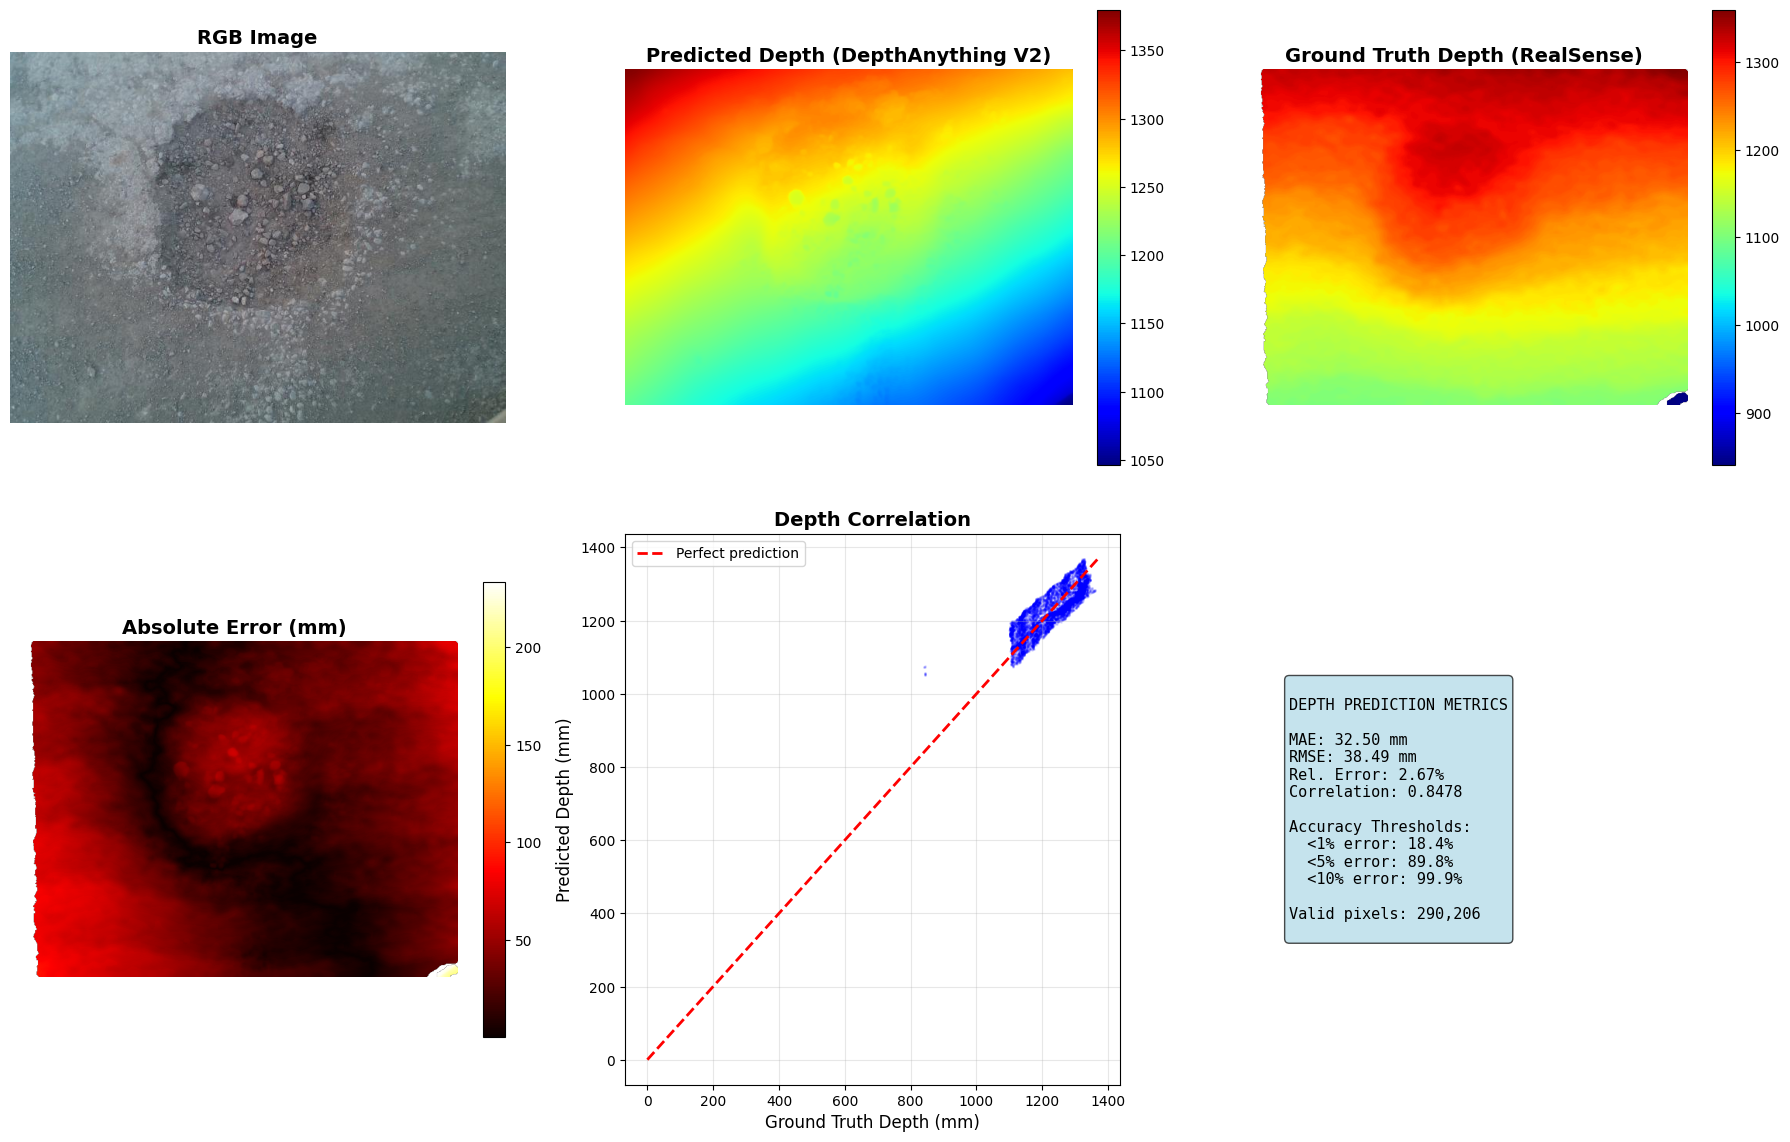

In [70]:
"""
DepthAnything V2 Integration for Pothole Volume Estimation
UPDATED VERSION - With proper installation handling
"""

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import torch
from tqdm import tqdm
import sys

# Add DepthAnything V2 to path
sys.path.append('Depth-Anything-V2')

# =============================================================================
# DEPTH ESTIMATION FUNCTIONS
# =============================================================================

def setup_depth_anything_v2(model_size='small', device='cuda'):
    # ADD THESE THREE LINES AT THE TOP OF THE FUNCTION
    import sys
    import os
    if os.path.abspath('Depth-Anything-V2') not in sys.path:
        sys.path.insert(0, os.path.abspath('Depth-Anything-V2'))

    # NOW the import will work
    from depth_anything_v2.dpt import DepthAnythingV2
    
    # Model configuration
    model_configs = {
        'vits': {'encoder': 'vits', 'features': 64, 'out_channels': [48, 96, 192, 384]},
        'vitb': {'encoder': 'vitb', 'features': 128, 'out_channels': [96, 192, 384, 768]},
        'vitl': {'encoder': 'vitl', 'features': 256, 'out_channels': [256, 512, 1024, 1024]}
    }
    
    encoder = 'vits' if model_size == 'small' else 'vitb' if model_size == 'base' else 'vitl'
    
    model = DepthAnythingV2(**model_configs[encoder])
    
    # Load weights
    checkpoint_paths = {
        'small': 'checkpoints/depth_anything_v2_vits.pth',
        'base': 'checkpoints/depth_anything_v2_vitb.pth',
        'large': 'checkpoints/depth_anything_v2_vitl.pth'
    }
    
    model.load_state_dict(torch.load(checkpoint_paths[model_size], map_location='cpu'))
    model = model.to(device).eval()
    
    print(f"✓ DepthAnything V2 ({model_size}) loaded successfully on {device}")
    
    return model


def predict_depth(model, rgb_image, device='cuda'):
    """
    Predict depth map from RGB image using DepthAnything V2
    
    Args:
        model: DepthAnything V2 model
        rgb_image: numpy array (H, W, 3) in RGB format
        device: 'cuda' or 'cpu'
    
    Returns:
        depth_map: numpy array (H, W) - relative depth (NOT in mm yet)
    """
    with torch.no_grad():
        # Inference
        depth = model.infer_image(rgb_image)  # Returns numpy array
    
    return depth


def align_depth_to_ground_truth(predicted_depth, ground_truth_depth, mask=None):
    """
    Align predicted relative depth to ground truth absolute depth
    Uses least squares to find optimal scale and shift
    
    Args:
        predicted_depth: (H, W) relative depth from DepthAnything
        ground_truth_depth: (H, W) absolute depth from RealSense (mm)
        mask: (H, W) optional mask to focus on specific region
    
    Returns:
        aligned_depth: (H, W) predicted depth scaled to mm
        scale: scale factor
        shift: shift offset
    """
    if mask is None:
        valid = (ground_truth_depth > 0) & (predicted_depth > 0)
    else:
        valid = (ground_truth_depth > 0) & (predicted_depth > 0) & (mask > 0)
    
    if np.sum(valid) < 100:
        print("  ⚠️ Warning: Less than 100 valid pixels for alignment")
        return predicted_depth, 1.0, 0.0
    
    pred_valid = predicted_depth[valid].flatten()
    gt_valid = ground_truth_depth[valid].flatten()
    
    # Solve: gt = scale * pred + shift
    # Using least squares: [scale, shift]^T = (A^T A)^-1 A^T b
    A = np.column_stack([pred_valid, np.ones_like(pred_valid)])
    b = gt_valid
    
    try:
        params = np.linalg.lstsq(A, b, rcond=None)[0]
        scale, shift = params
    except:
        # Fallback to simple scaling
        scale = np.median(gt_valid / (pred_valid + 1e-8))
        shift = 0
    
    aligned_depth = scale * predicted_depth + shift
    
    return aligned_depth, scale, shift


def calculate_depth_metrics(predicted_depth, ground_truth_depth, mask=None):
    """
    Calculate error metrics between predicted and ground truth depth
    
    Returns:
        dict with MAE, RMSE, relative error, etc.
    """
    if mask is None:
        valid = (ground_truth_depth > 0) & (predicted_depth > 0)
    else:
        valid = (ground_truth_depth > 0) & (predicted_depth > 0) & (mask > 0)
    
    if np.sum(valid) < 10:
        return None
    
    pred = predicted_depth[valid].flatten()
    gt = ground_truth_depth[valid].flatten()
    
    # Absolute errors
    abs_diff = np.abs(pred - gt)
    mae = np.mean(abs_diff)
    rmse = np.sqrt(np.mean((pred - gt) ** 2))
    
    # Relative errors
    rel_error = np.mean(abs_diff / (gt + 1e-8))
    
    # Threshold accuracies (% of pixels within X% error)
    thresh_1 = np.mean(abs_diff / (gt + 1e-8) < 0.01)  # <1% error
    thresh_5 = np.mean(abs_diff / (gt + 1e-8) < 0.05)  # <5% error
    thresh_10 = np.mean(abs_diff / (gt + 1e-8) < 0.10)  # <10% error
    
    # Correlation
    correlation = np.corrcoef(pred, gt)[0, 1] if len(pred) > 1 else 0
    
    return {
        'mae': mae,
        'rmse': rmse,
        'rel_error': rel_error,
        'thresh_1pct': thresh_1,
        'thresh_5pct': thresh_5,
        'thresh_10pct': thresh_10,
        'correlation': correlation,
        'num_pixels': np.sum(valid)
    }


# =============================================================================
# VISUALIZATION
# =============================================================================

def visualize_depth_comparison(rgb_image, predicted_depth, ground_truth_depth, 
                               metrics=None, save_path='depth_comparison.png'):
    """
    Create side-by-side comparison of predicted vs ground truth depth
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Row 1: Images
    axes[0, 0].imshow(rgb_image)
    axes[0, 0].set_title('RGB Image', fontsize=14, fontweight='bold')
    axes[0, 0].axis('off')
    
    pred_display = predicted_depth.copy()
    pred_display[pred_display <= 0] = np.nan
    im1 = axes[0, 1].imshow(pred_display, cmap='jet', vmin=np.nanmin(pred_display), vmax=np.nanmax(pred_display))
    axes[0, 1].set_title('Predicted Depth (DepthAnything V2)', fontsize=14, fontweight='bold')
    axes[0, 1].axis('off')
    plt.colorbar(im1, ax=axes[0, 1], fraction=0.046)
    
    gt_display = ground_truth_depth.copy().astype(float)
    gt_display[gt_display <= 0] = np.nan
    im2 = axes[0, 2].imshow(gt_display, cmap='jet', vmin=np.nanmin(gt_display), vmax=np.nanmax(gt_display))
    axes[0, 2].set_title('Ground Truth Depth (RealSense)', fontsize=14, fontweight='bold')
    axes[0, 2].axis('off')
    plt.colorbar(im2, ax=axes[0, 2], fraction=0.046)
    
    # Row 2: Analysis
    valid_mask = (ground_truth_depth > 0) & (predicted_depth > 0)
    diff = np.abs(predicted_depth - ground_truth_depth)
    diff[~valid_mask] = np.nan
    im3 = axes[1, 0].imshow(diff, cmap='hot')
    axes[1, 0].set_title('Absolute Error (mm)', fontsize=14, fontweight='bold')
    axes[1, 0].axis('off')
    plt.colorbar(im3, ax=axes[1, 0], fraction=0.046)
    
    # Scatter plot
    valid = (ground_truth_depth > 0) & (predicted_depth > 0)
    if np.sum(valid) > 10:
        # Subsample for plotting
        indices = np.where(valid)
        sample_size = min(10000, len(indices[0]))
        sample_idx = np.random.choice(len(indices[0]), sample_size, replace=False)
        
        gt_sample = ground_truth_depth[indices[0][sample_idx], indices[1][sample_idx]]
        pred_sample = predicted_depth[indices[0][sample_idx], indices[1][sample_idx]]
        
        axes[1, 1].scatter(gt_sample, pred_sample, 
                          alpha=0.1, s=1, c='blue')
        
        max_val = max(np.max(gt_sample), np.max(pred_sample))
        axes[1, 1].plot([0, max_val], [0, max_val], 
                        'r--', linewidth=2, label='Perfect prediction')
        axes[1, 1].set_xlabel('Ground Truth Depth (mm)', fontsize=12)
        axes[1, 1].set_ylabel('Predicted Depth (mm)', fontsize=12)
        axes[1, 1].set_title('Depth Correlation', fontsize=14, fontweight='bold')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
    
    # Error histogram or metrics text
    if metrics:
        axes[1, 2].axis('off')
        
        metrics_text = f"""
DEPTH PREDICTION METRICS

MAE: {metrics['mae']:.2f} mm
RMSE: {metrics['rmse']:.2f} mm
Rel. Error: {metrics['rel_error']*100:.2f}%
Correlation: {metrics['correlation']:.4f}

Accuracy Thresholds:
  <1% error: {metrics['thresh_1pct']*100:.1f}%
  <5% error: {metrics['thresh_5pct']*100:.1f}%
  <10% error: {metrics['thresh_10pct']*100:.1f}%

Valid pixels: {metrics['num_pixels']:,}
"""
        
        axes[1, 2].text(0.1, 0.5, metrics_text, fontsize=11, family='monospace',
                       verticalalignment='center', bbox=dict(boxstyle='round', 
                       facecolor='lightblue', alpha=0.7))
    else:
        error_valid = diff[~np.isnan(diff)]
        if len(error_valid) > 0:
            axes[1, 2].hist(error_valid, bins=50, alpha=0.7, color='red', edgecolor='black')
            axes[1, 2].set_xlabel('Absolute Error (mm)', fontsize=12)
            axes[1, 2].set_ylabel('Frequency', fontsize=12)
            axes[1, 2].set_title('Error Distribution', fontsize=14, fontweight='bold')
            axes[1, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"✓ Saved: {save_path}")
    
    return fig


# =============================================================================
# BATCH PROCESSING
# =============================================================================

def process_dataset(base_path, output_dir='depth_anything_predictions', 
                   num_samples=None, model_size='small', device='cuda'):
    """
    Process entire PothRGBD dataset with DepthAnything V2
    """
    base_path = Path(base_path)
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True)
    
    images_dir = base_path / 'images'
    depths_dir = base_path / 'depths'
    
    # Get file lists
    image_files = sorted(list(images_dir.glob('*.jpg')))
    depth_files = sorted(list(depths_dir.glob('*.npy')))
    
    if num_samples:
        image_files = image_files[:num_samples]
        depth_files = depth_files[:num_samples]
    
    print(f"Processing {len(image_files)} images...")
    
    # Load model
    model = setup_depth_anything_v2(model_size=model_size, device=device)
    
    # Process each image
    results = []
    
    for i, (img_path, depth_path) in enumerate(tqdm(
        zip(image_files, depth_files), 
        total=len(image_files),
        desc="Predicting depth"
    )):
        try:
            # Load RGB
            rgb = cv2.imread(str(img_path))
            rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)
            
            # Load ground truth depth
            gt_depth = np.load(depth_path)
            
            # Predict depth
            pred_depth_relative = predict_depth(model, rgb, device=device)
            
            # Align to ground truth scale
            aligned_depth, scale, shift = align_depth_to_ground_truth(
                pred_depth_relative, gt_depth
            )
            
            # Save predicted depth
            output_path = output_dir / f"{img_path.stem}_depth_pred.npy"
            np.save(output_path, aligned_depth)
            
            # Calculate metrics
            metrics = calculate_depth_metrics(aligned_depth, gt_depth)
            
            if metrics:
                results.append({
                    'index': i,
                    'filename': img_path.name,
                    'scale': scale,
                    'shift': shift,
                    **metrics
                })
        except Exception as e:
            print(f"Error processing {img_path.name}: {e}")
            continue
    
    return results


# =============================================================================
# MAIN EXECUTION
# =============================================================================

if __name__ == "__main__":
    print("="*70)
    print("DEPTHANYTHING V2 INTEGRATION FOR POTHOLE VOLUME ESTIMATION")
    print("="*70)
    
    # Configuration
    # BASE_PATH = Path('/kaggle/input/pothrgbd-rgb-and-depth-images-of-potholes/PUBLIC POTHOLE DATASET')
    BASE_PATH = Path(r'C:\Users\Admin\.cache\kagglehub\datasets\mahyeks\pothrgbd-rgb-and-depth-images-of-potholes\versions\1\PUBLIC POTHOLE DATASET')
    OUTPUT_DIR = Path('depth_anything_predictions')
    
    # Test on a single image first
    print("\n" + "="*70)
    print("STEP 1: Single Image Test")
    print("="*70)
    
    # images_dir = BASE_PATH / 'images'
    # depths_dir = BASE_PATH / 'depths'

    images_dir = os.path.join(BASE_PATH,'images')
    depths_dir = os.path.join(BASE_PATH,'depths')
    # labels_dir = os.path.join(base_path,'labels')
    
    # image_files = sorted(list(images_dir.glob('*.jpg')))
    # depth_files = sorted(list(depths_dir.glob('*.npy')))

    image_files = sorted(glob.glob(images_dir + "/*.jpg"))
    depth_files = sorted(glob.glob(depths_dir + "/*.npy"))
    # label_files = sorted(glob.glob(labels_dir + "/*.txt"))
    
    test_idx = 200
    
    print(f"\nTesting on sample #{test_idx}...")
    
    # Load data
    rgb = cv2.imread(str(image_files[test_idx]))
    rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)
    gt_depth = np.load(depth_files[test_idx])
    
    # Setup model
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Using device: {device}")
    
    model = setup_depth_anything_v2(model_size='small', device=device)
    
    # Predict depth
    print("\nPredicting depth...")
    pred_depth_relative = predict_depth(model, rgb, device=device)
    
    print(f"  Predicted depth shape: {pred_depth_relative.shape}")
    print(f"  Predicted depth range: [{pred_depth_relative.min():.2f}, {pred_depth_relative.max():.2f}]")
    
    # Align to ground truth
    print("\nAligning to ground truth scale...")
    aligned_depth, scale, shift = align_depth_to_ground_truth(
        pred_depth_relative, gt_depth
    )
    
    print(f"  Scale factor: {scale:.4f}")
    print(f"  Shift offset: {shift:.4f} mm")
    
    # Calculate metrics
    print("\nCalculating metrics...")
    metrics = calculate_depth_metrics(aligned_depth, gt_depth)
    
    if metrics:
        print("\n📊 Depth Prediction Metrics:")
        print(f"  MAE: {metrics['mae']:.2f} mm")
        print(f"  RMSE: {metrics['rmse']:.2f} mm")
        print(f"  Relative Error: {metrics['rel_error']*100:.2f}%")
        print(f"  Correlation: {metrics['correlation']:.4f}")
        print(f"  Pixels <5% error: {metrics['thresh_5pct']*100:.1f}%")
        print(f"  Pixels <10% error: {metrics['thresh_10pct']*100:.1f}%")
    
    # Visualize
    print("\nCreating visualization...")
    visualize_depth_comparison(rgb, aligned_depth, gt_depth, metrics,
                              save_path='depth_prediction_comparison.png')
    
    # Batch processing
    print("\n" + "="*70)
    print("STEP 2: Batch Processing")
    print("="*70)
    print("Process how many samples? (recommended: 100 first, then 1000)")
    
    # Change this number as needed
    NUM_SAMPLES = 100
    
    results = process_dataset(
        BASE_PATH, 
        output_dir=OUTPUT_DIR,
        num_samples=NUM_SAMPLES,
        model_size='small',
        device=device
    )
    
    # Save results
    import pandas as pd
    df = pd.DataFrame(results)
    df.to_csv('depth_prediction_results.csv', index=False)
    print(f"\n✓ Saved results to: depth_prediction_results.csv")
    
    # Aggregate statistics
    print("\n" + "="*70)
    print("AGGREGATE STATISTICS")
    print("="*70)
    
    if len(results) > 0:
        mae_values = [r['mae'] for r in results]
        rmse_values = [r['rmse'] for r in results]
        rel_error_values = [r['rel_error'] for r in results]
        correlation_values = [r['correlation'] for r in results]
        
        print(f"\nMAE (mm):")
        print(f"  Mean: {np.mean(mae_values):.2f}")
        print(f"  Median: {np.median(mae_values):.2f}")
        print(f"  Min: {np.min(mae_values):.2f}")
        print(f"  Max: {np.max(mae_values):.2f}")
        
        print(f"\nRMSE (mm):")
        print(f"  Mean: {np.mean(rmse_values):.2f}")
        print(f"  Median: {np.median(rmse_values):.2f}")
        
        print(f"\nRelative Error (%):")
        print(f"  Mean: {np.mean(rel_error_values)*100:.2f}%")
        print(f"  Median: {np.median(rel_error_values)*100:.2f}%")
        
        print(f"\nCorrelation:")
        print(f"  Mean: {np.mean(correlation_values):.4f}")
        print(f"  Median: {np.median(correlation_values):.4f}")
        
        # Decision criteria
        print("\n" + "="*70)
        print("FEASIBILITY ASSESSMENT")
        print("="*70)
        
        mean_mae = np.mean(mae_values)
        mean_corr = np.mean(correlation_values)
        
        if mean_mae < 50 and mean_corr > 0.9:
            print("✓ EXCELLENT - Proceed to volume estimation!")
            print("  Your monocular depth is LiDAR-comparable")
        elif mean_mae < 100 and mean_corr > 0.8:
            print("✓ GOOD - Proceed with volume estimation")
            print("  Expect 10-20% volume error (still publishable)")
        else:
            print("⚠ NEEDS IMPROVEMENT")
            print("  Consider fine-tuning DepthAnything V2 on your dataset")
    
    print("\n" + "="*70)
    print("DONE!")
    print("="*70)